## Finetuned Model Post-Processing

**Heads**

Default: your custom head (for the dataset you gave `--train-file` earlier)

pt_head: pre-training/replay head, samples drawn from the replay .xyz file, a snapshot of the original foundation model's training set

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# ==== USER INPUT HERE ====
RUN_ID = 733132 #732830

out_file = f"mace_{str(RUN_ID)}.out"
err_file = f"mace_{str(RUN_ID)}.err"
train_script = f"train_{str(RUN_ID)}.sbatch"

In [11]:
# load in job.out generated by training run

pattern = re.compile(
    r"(?:Epoch (\d+)|(Initial)): head: (\S+), "
    r"loss=([\d.]+), "
    r"RMSE_E_per_atom=\s*([\d.]+) meV, "
    r"RMSE_F=\s*([\d.]+) meV / A, "
    r"RMSE_stress=\s*(None|[\d.]+) meV / A\^3"
)

with open(f"../logs/{out_file}", "r") as f:
    log_out = f.read()

matches = pattern.findall(log_out)

rows = [
    (epoch_num if epoch_num else "-1", *rest)
    for epoch_num, _initial, *rest in matches
]

# make dataframe of epoch readouts
df = pd.DataFrame(
    rows,
    columns=["epoch", "head", "loss", "RMSE_E_per_atom", "RMSE_F", "RMSE_stress"]
)

for col in ["epoch", "loss", "RMSE_E_per_atom", "RMSE_F"]:
    df[col] = pd.to_numeric(df[col])

df["RMSE_stress"] = pd.to_numeric(df["RMSE_stress"], errors="coerce")

# separate out dfs for each model head
df_default = df[df["head"] == "Default"]
df_pt = df[df["head"] == "pt_head"]

print(f"df length: {len(df_default)}")

df length: 11


In [12]:
# get learning rate params

with open(f"../logs/{train_script}", "r") as f:
    text = f.read()

lr = re.search(r"--lr (\d+\.\d+)", text)
swa_lr = re.search(r"--swa_lr (\d+\.\d+)", text)

lr = float(lr.group(1)) if lr else None
swa_lr = float(swa_lr.group(1)) if swa_lr else None

# print(text)

FileNotFoundError: [Errno 2] No such file or directory: '../logs/train_733132.sbatch'

Graph Loss

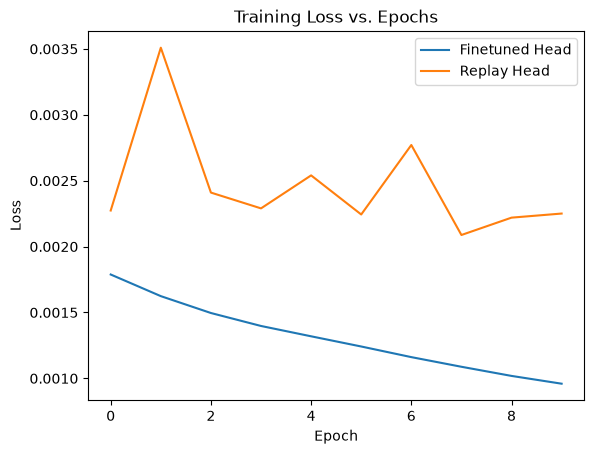

In [13]:
# remove meaningless initial point of tuned head
df_default_plot = df_default[df_default["epoch"] != -1]
df_pt_plot = df_pt[df_pt["epoch"] != -1]

# plot loss curves
plt.plot(df_default_plot["epoch"], df_default_plot["loss"], label="Finetuned Head")
plt.plot(df_pt_plot["epoch"], df_pt_plot["loss"], label="Replay Head")

# # plot initial guess (zero-shot)
# plt.scatter(
#     df_default["epoch"].iloc[0],
#     df_default["loss"].iloc[0],
#     marker=".", s=100, color="darkorange", zorder=5, label="Zero-shot"
# )

# print learning rates
# plt.text(
#     0.2, 0.95,
#     f"lr={lr}, swa_lr={swa_lr}",
#     transform=plt.gca().transAxes,
#     ha="left",
#     va="top",
# )

plt.title("Training Loss vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# print(f"lr: {lr}, swa_lr: {swa_lr}")

Graph RMSE

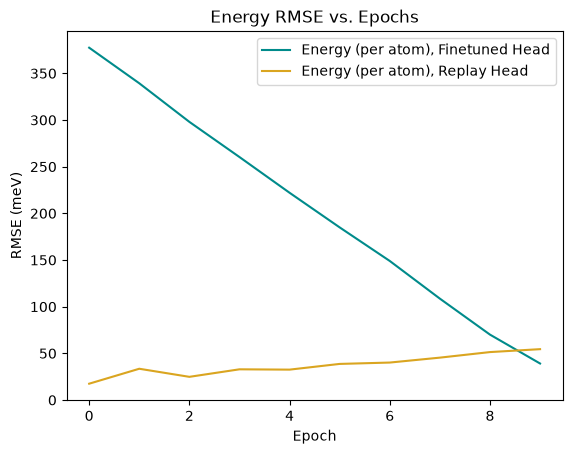

In [14]:
# plot energy RMSEs
plt.plot(df_default_plot["epoch"], df_default_plot["RMSE_E_per_atom"], label="Energy (per atom), Finetuned Head", color="darkcyan")

plt.plot(df_pt_plot["epoch"], df_pt_plot["RMSE_E_per_atom"], label="Energy (per atom), Replay Head", color="goldenrod")


plt.title("Energy RMSE vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("RMSE (meV)")
plt.legend()

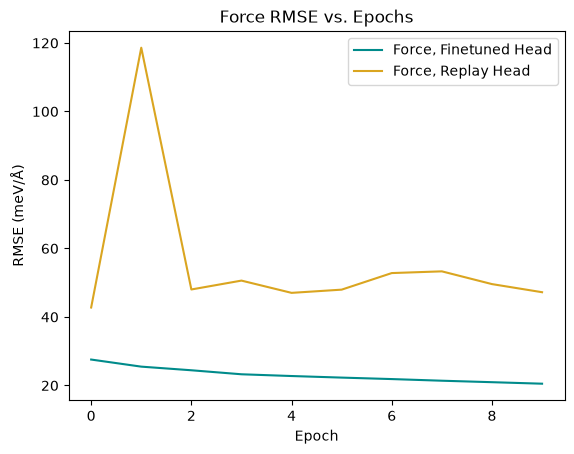

In [15]:
# plot force RMSEs
plt.plot(df_default_plot["epoch"], df_default_plot["RMSE_F"], label="Force, Finetuned Head", color="darkcyan")

plt.plot(df_pt_plot["epoch"], df_pt_plot["RMSE_F"], label="Force, Replay Head", color="goldenrod")

plt.title("Force RMSE vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("RMSE (meV/Å)")
plt.legend()

**Validation Set Error**

In [21]:
with open(f"../logs/{out_file}", "r") as f:
    text = f.read()

init_pattern = re.compile(
    r"Initial:\s+head:\s+Default.*?RMSE_E_per_atom=\s*([\d.]+).*?RMSE_F=\s*([\d.]+)"
)
fin_pattern = re.compile(
    r"\|\s+valid_Default\s+\|\s+([\d.]+)\s+\|\s+([\d.]+)\s+\|"
)

init_match = init_pattern.search(text)
fin_matches = fin_pattern.findall(text)  # one per printed Error-table
final = fin_matches[-1]                  # 2nd/final table = post-SWA

print(f"{'':<16} {'RMSE E':>12} {'RMSE F':>12}")
print("-" * 42)
print(f"{'Base Model':<16} {init_match.group(1):>12} {init_match.group(2):>12}")
print(f"{'Finetuned Model':<16} {final[0]:>12} {final[1]:>12}")

                       RMSE E       RMSE F
------------------------------------------
Base Model             432.74        67.09
Finetuned Model          20.3         17.9


## Compare Multiple Runs

In [6]:
# ==== USER INPUT HERE ====

RUN_IDS = [732830, 733132]

In [7]:
# load in job.out generated by each training run and make df

pattern = re.compile(
    r"(?:Epoch (\d+)|(Initial)): head: (\S+), "
    r"loss=([\d.]+), "
    r"RMSE_E_per_atom=\s*([\d.]+) meV, "
    r"RMSE_F=\s*([\d.]+) meV / A, "
    r"RMSE_stress=\s*(None|[\d.]+) meV / A\^3"
)


def make_run_df(run_id):
    with open(f"../logs/mace_{run_id}.out") as f:
        log_out = f.read()

    matches = pattern.findall(log_out)

    rows = [
        (epoch_num if epoch_num else "-1", *rest)
        for epoch_num, _initial, *rest in matches
    ]

    # make dataframe of epoch readouts
    df = pd.DataFrame(
        rows,
        columns=["epoch", "head", "loss", "RMSE_E_per_atom", "RMSE_F", "RMSE_stress"]
    )

    for col in ["epoch", "loss", "RMSE_E_per_atom", "RMSE_F"]:
        df[col] = pd.to_numeric(df[col])

    df["RMSE_stress"] = pd.to_numeric(df["RMSE_stress"], errors="coerce")

    # separate out dfs for each model head
    df_ft = df[df["head"] == "Default"]
    df_pt = df[df["head"] == "pt_head"]

    return df_ft, df_pt

In [8]:
run_dfs = {}

for run_id in RUN_IDS:
    df_ft, df_pt = make_run_df(run_id)

    run_dfs[run_id] = {
        "ft": df_ft,
        "pt": df_pt,
    }    

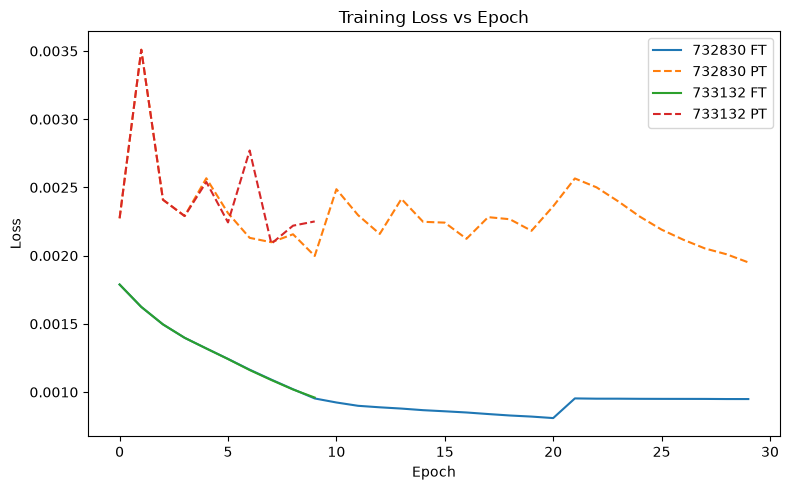

In [9]:
plt.figure(figsize=(8, 5))

for run_id, dfs in run_dfs.items():
    df_ft = dfs["ft"]
    df_pt = dfs["pt"]

    # remove meaningless initial point
    df_ft = df_ft[df_ft["epoch"] != -1]
    df_pt = df_pt[df_pt["epoch"] != -1]

    plt.plot(
        df_ft["epoch"],
        df_ft["loss"],
        label=f"{run_id} FT",
    )

    plt.plot(
        df_pt["epoch"],
        df_pt["loss"],
        "--",
        label=f"{run_id} PT",
    )

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

### Notes

**run_731507**
Zero-shot: for pt_head (the replay head) @ epoch 0, RMSE_E_per_atom: 105.68, RMSE_F: 54.28

**run_731457**

Loss curves indicate
* Catastrophic forgetting: finetuned loss jumps far above replay at the end
 
3 main issues:
1. massive jump in loss from epoch 20 --> 21. to me, this indicates an issue with how SWA is being set/used
2. post-SWA doesn't have enough epochs to potentially converge. 30 is not many epochs, but the finetuning docs said this should converge in 10-30 epochs
3. we didn't really seem to use the first 20 epochs well? loss decreases for the first 5 epochs but then kind of levels off and skips around. the finetune head has min loss around epoch 6, and the replay head hits a min loss around epochs 6 and 20

default lr=0.01, our lr=0.0005
default swa_lr=0.001, our swa_lr=default

On learning rate:  
b/c we have a small dataset (compared to what the literature uses for finetuning MACE), i decreased the lr. smaller corpus --> fewer samples per batch --> noisier\* gradient estimates --> large step size overshoots local minima 

however, swa<=lr, usually set swa = lr/(10-100) 
looking back, finetuning lr=0.0001 in some lit., so lower that as well

\* (higher variance in estimate of "true" gradient, the gradient of loss computed over the entire dataset)